# 01 — Build Manifest
# Giai đoạn 1 — Mục 1.1 — Đọc manifest đã lọc (hoặc xây dựng lại)
 **Đầu ra**: `outputs/tables/manifest_filtered.csv`

In [1]:
from pathlib import Path
import pandas as pd
from common import pipeline, io_utils

In [2]:
USE_SYNTHETIC_DATA = False
REAL_DATA_ROOT = Path("../../data/raw")
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")

FORCE_REBUILD_MANIFEST = False

TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

- NẾU MANIFEST ĐÃ TỒN TẠI

In [3]:
try:
    manifest_full = pipeline.get_manifest(
        use_synthetic=USE_SYNTHETIC_DATA,
        real_data_root=REAL_DATA_ROOT,
        synthetic_data_root=SYNTHETIC_DATA_ROOT,
        output_dir=OUTPUT_DIR,
        force_rebuild=FORCE_REBUILD_MANIFEST,
    )
except AssertionError as e:
    print(f"[LỖI khi build_manifest] {e}")
    print("Đang dò lại thủ công (không qua bước validate) để xác định "
          "CHÍNH XÁC (các) file đang thiếu resolved_sample_rate_hz...\n")
    data_root = SYNTHETIC_DATA_ROOT if USE_SYNTHETIC_DATA else REAL_DATA_ROOT
    raw_manifest = io_utils.build_manifest(data_root)
    missing_rows = raw_manifest[raw_manifest["resolved_sample_rate_hz"].isna()]
    display(missing_rows[["file_path", "label", "load_hp", "warnings"]])
    raise RuntimeError(
        f"{len(missing_rows)} file ở bảng trên chưa xác định được sampling "
        "rate thực (xem cột 'warnings'). Cần kiểm tra thủ công file(s) này "
        "và bổ sung luật suy luận phù hợp trong "
        "io_utils.run_sanity_checks(), hoặc loại trừ file khỏi manifest "
        "TRƯỚC khi chạy tiếp notebook. TUYỆT ĐỐI không gán fs mặc định "
        "(ví dụ 12000 Hz) một cách võ đoán -- làm vậy sẽ làm sai toàn bộ "
        "tần số lỗi tính ở Giai đoạn 1/2."
    ) from e

# Official manifest flow: cache/load -> sanity contract -> scope filter.
# get_manifest() rebuilds stale caches when its schema is incomplete.
manifest = io_utils.apply_scope_filter(manifest_full)
manifest_path = TABLES_DIR / "manifest_filtered.csv"

required_cols = [
    "file_path", "label", "load_hp", "fault_diameter_mils",
    "warnings", "has_warning", "resolved_sample_rate_hz",
]
missing = [c for c in required_cols if c not in manifest.columns]
assert not missing, f"Manifest sau apply_scope_filter() thiếu cột: {missing}"
assert manifest["file_path"].is_unique, "Có file_path trùng lặp trong manifest!"
assert not manifest["resolved_sample_rate_hz"].isna().any(), (
    "Manifest còn file chưa xác định được sampling rate thực. "
    "Không được suy đoán fs trước khi chạy Giai đoạn 1."
)

manifest.to_csv(manifest_path, index=False)
print(f"Đã xây dựng và lưu manifest đã lọc: {manifest_path}")

print(f"Số file trong manifest: {len(manifest)}")
manifest.head()

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.
Đã xây dựng và lưu manifest đã lọc: outputs\tables\manifest_filtered.csv
Số file trong manifest: 40


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning,resolved_sample_rate_hz
0,data\raw\12k_Drive_End_Bearing_Fault_Data\B\00...,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,NaN,NaN,False,12000.0
1,data\raw\12k_Drive_End_Bearing_Fault_Data\B\00...,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,NaN,NaN,False,12000.0
2,data\raw\12k_Drive_End_Bearing_Fault_Data\B\00...,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,NaN,NaN,False,12000.0
3,data\raw\12k_Drive_End_Bearing_Fault_Data\B\00...,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,NaN,NaN,False,12000.0
4,data\raw\12k_Drive_End_Bearing_Fault_Data\B\01...,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,NaN,NaN,False,12000.0


# Sanity check

In [4]:
n_warn = int(manifest["has_warning"].sum())
print(f"Số file có cảnh báo: {n_warn} / {len(manifest)}\n")

if n_warn > 0:
    warn_cols = ["file_path", "label", "load_hp", "fault_diameter_mils", "warnings"]
    warn_df = manifest.loc[manifest["has_warning"], warn_cols]
    warn_df.to_csv(TABLES_DIR / "01_warnings.csv", index=False)
    display(warn_df)
else:
    print("Không có cảnh báo nào trên bộ dữ liệu hiện tại.")

Số file có cảnh báo: 4 / 40



,file_path,label,load_hp,fault_diameter_mils,warnings
36,data\raw\Normal\100_Normal_3.mat,Normal,3,NaN,NGHI_NGO_SAMPLING_RATE: n_samples=485643 (12kH...
37,data\raw\Normal\97_Normal_0.mat,Normal,0,NaN,NGHI_NGO_SAMPLING_RATE: n_samples=243938 (12kH...
38,data\raw\Normal\98_Normal_1.mat,Normal,1,NaN,NGHI_NGO_SAMPLING_RATE: n_samples=483903 (12kH...
39,data\raw\Normal\99_Normal_2.mat,Normal,2,NaN,NGHI_NGO_SAMPLING_RATE: n_samples=485063 (12kH...


In [5]:
# --- Kiểm tra toàn vẹn manifest trước khi dùng cho các bước sau ---
assert manifest["file_path"].is_unique, "Có file_path trùng lặp trong manifest!"

required_cols = ["label", "load_hp", "rpm_from_file", "resolved_sample_rate_hz"]
na_counts = manifest[required_cols].isna().sum()
if na_counts.any():
    print("[CẢNH BÁO] Có giá trị thiếu ở cột bắt buộc:")
    print(na_counts[na_counts > 0])

# Phân bố lớp — kiểm tra cân bằng cho LOLO (RQ1) và phân loại 10 lớp (RQ2)
print("\nPhân bố label x load_hp:")
print(pd.crosstab(manifest["label"], manifest["load_hp"]))

# Các file còn cảnh báo NHẸ (không bị loại nhưng cần bạn tự xem xét)
still_warned = manifest[manifest["has_warning"]]
if len(still_warned):
    print(f"\n[XEM XÉT] {len(still_warned)} file còn cảnh báo chưa xử lý:")
    print(still_warned[["file_path", "warnings"]].to_string(index=False))
else:
    print("\nKhông còn file nào có cảnh báo trong tập đã lọc.")

[CẢNH BÁO] Có giá trị thiếu ở cột bắt buộc:
rpm_from_file    2
dtype: int64

Phân bố label x load_hp:
load_hp  0  1  2  3
label              
B        3  3  3  3
IR       3  3  3  3
Normal   1  1  1  1
OR       3  3  3  3

[XEM XÉT] 4 file còn cảnh báo chưa xử lý:
                       file_path                                                                                                                                                                              warnings
data\raw\Normal\100_Normal_3.mat NGHI_NGO_SAMPLING_RATE: n_samples=485643 (12kHz->40.5s, 24kHz->20.2s, 48kHz->10.1s). Rate hợp lý nhất: 48kHz — KHÁC rate mà file tự nhận (12kHz, qua thư mục nguồn/phạm vi mục tiêu).
 data\raw\Normal\97_Normal_0.mat  NGHI_NGO_SAMPLING_RATE: n_samples=243938 (12kHz->20.3s, 24kHz->10.2s, 48kHz->5.1s). Rate hợp lý nhất: 24kHz — KHÁC rate mà file tự nhận (12kHz, qua thư mục nguồn/phạm vi mục tiêu).
 data\raw\Normal\98_Normal_1.mat NGHI_NGO_SAMPLING_RATE: n_samples=483903 (12kHz->40.3s, 2

- load 1, 2 Normal NaN -- không gây ảnh hưởng đến giai đoạn sau -- vì sử dụng NOMINAL_RPM_BY_LOAD ở config.py

In [6]:
# In ra 4 file Normal để tận mắt kiểm chứng sự thay đổi của cột rpm_from_file
display(manifest[manifest['label'] == 'Normal'][['file_path', 'load_hp', 'rpm_from_file']])

,file_path,load_hp,rpm_from_file
36,data\raw\Normal\100_Normal_3.mat,3,1725.0
37,data\raw\Normal\97_Normal_0.mat,0,1796.0
38,data\raw\Normal\98_Normal_1.mat,1,NaN
39,data\raw\Normal\99_Normal_2.mat,2,NaN


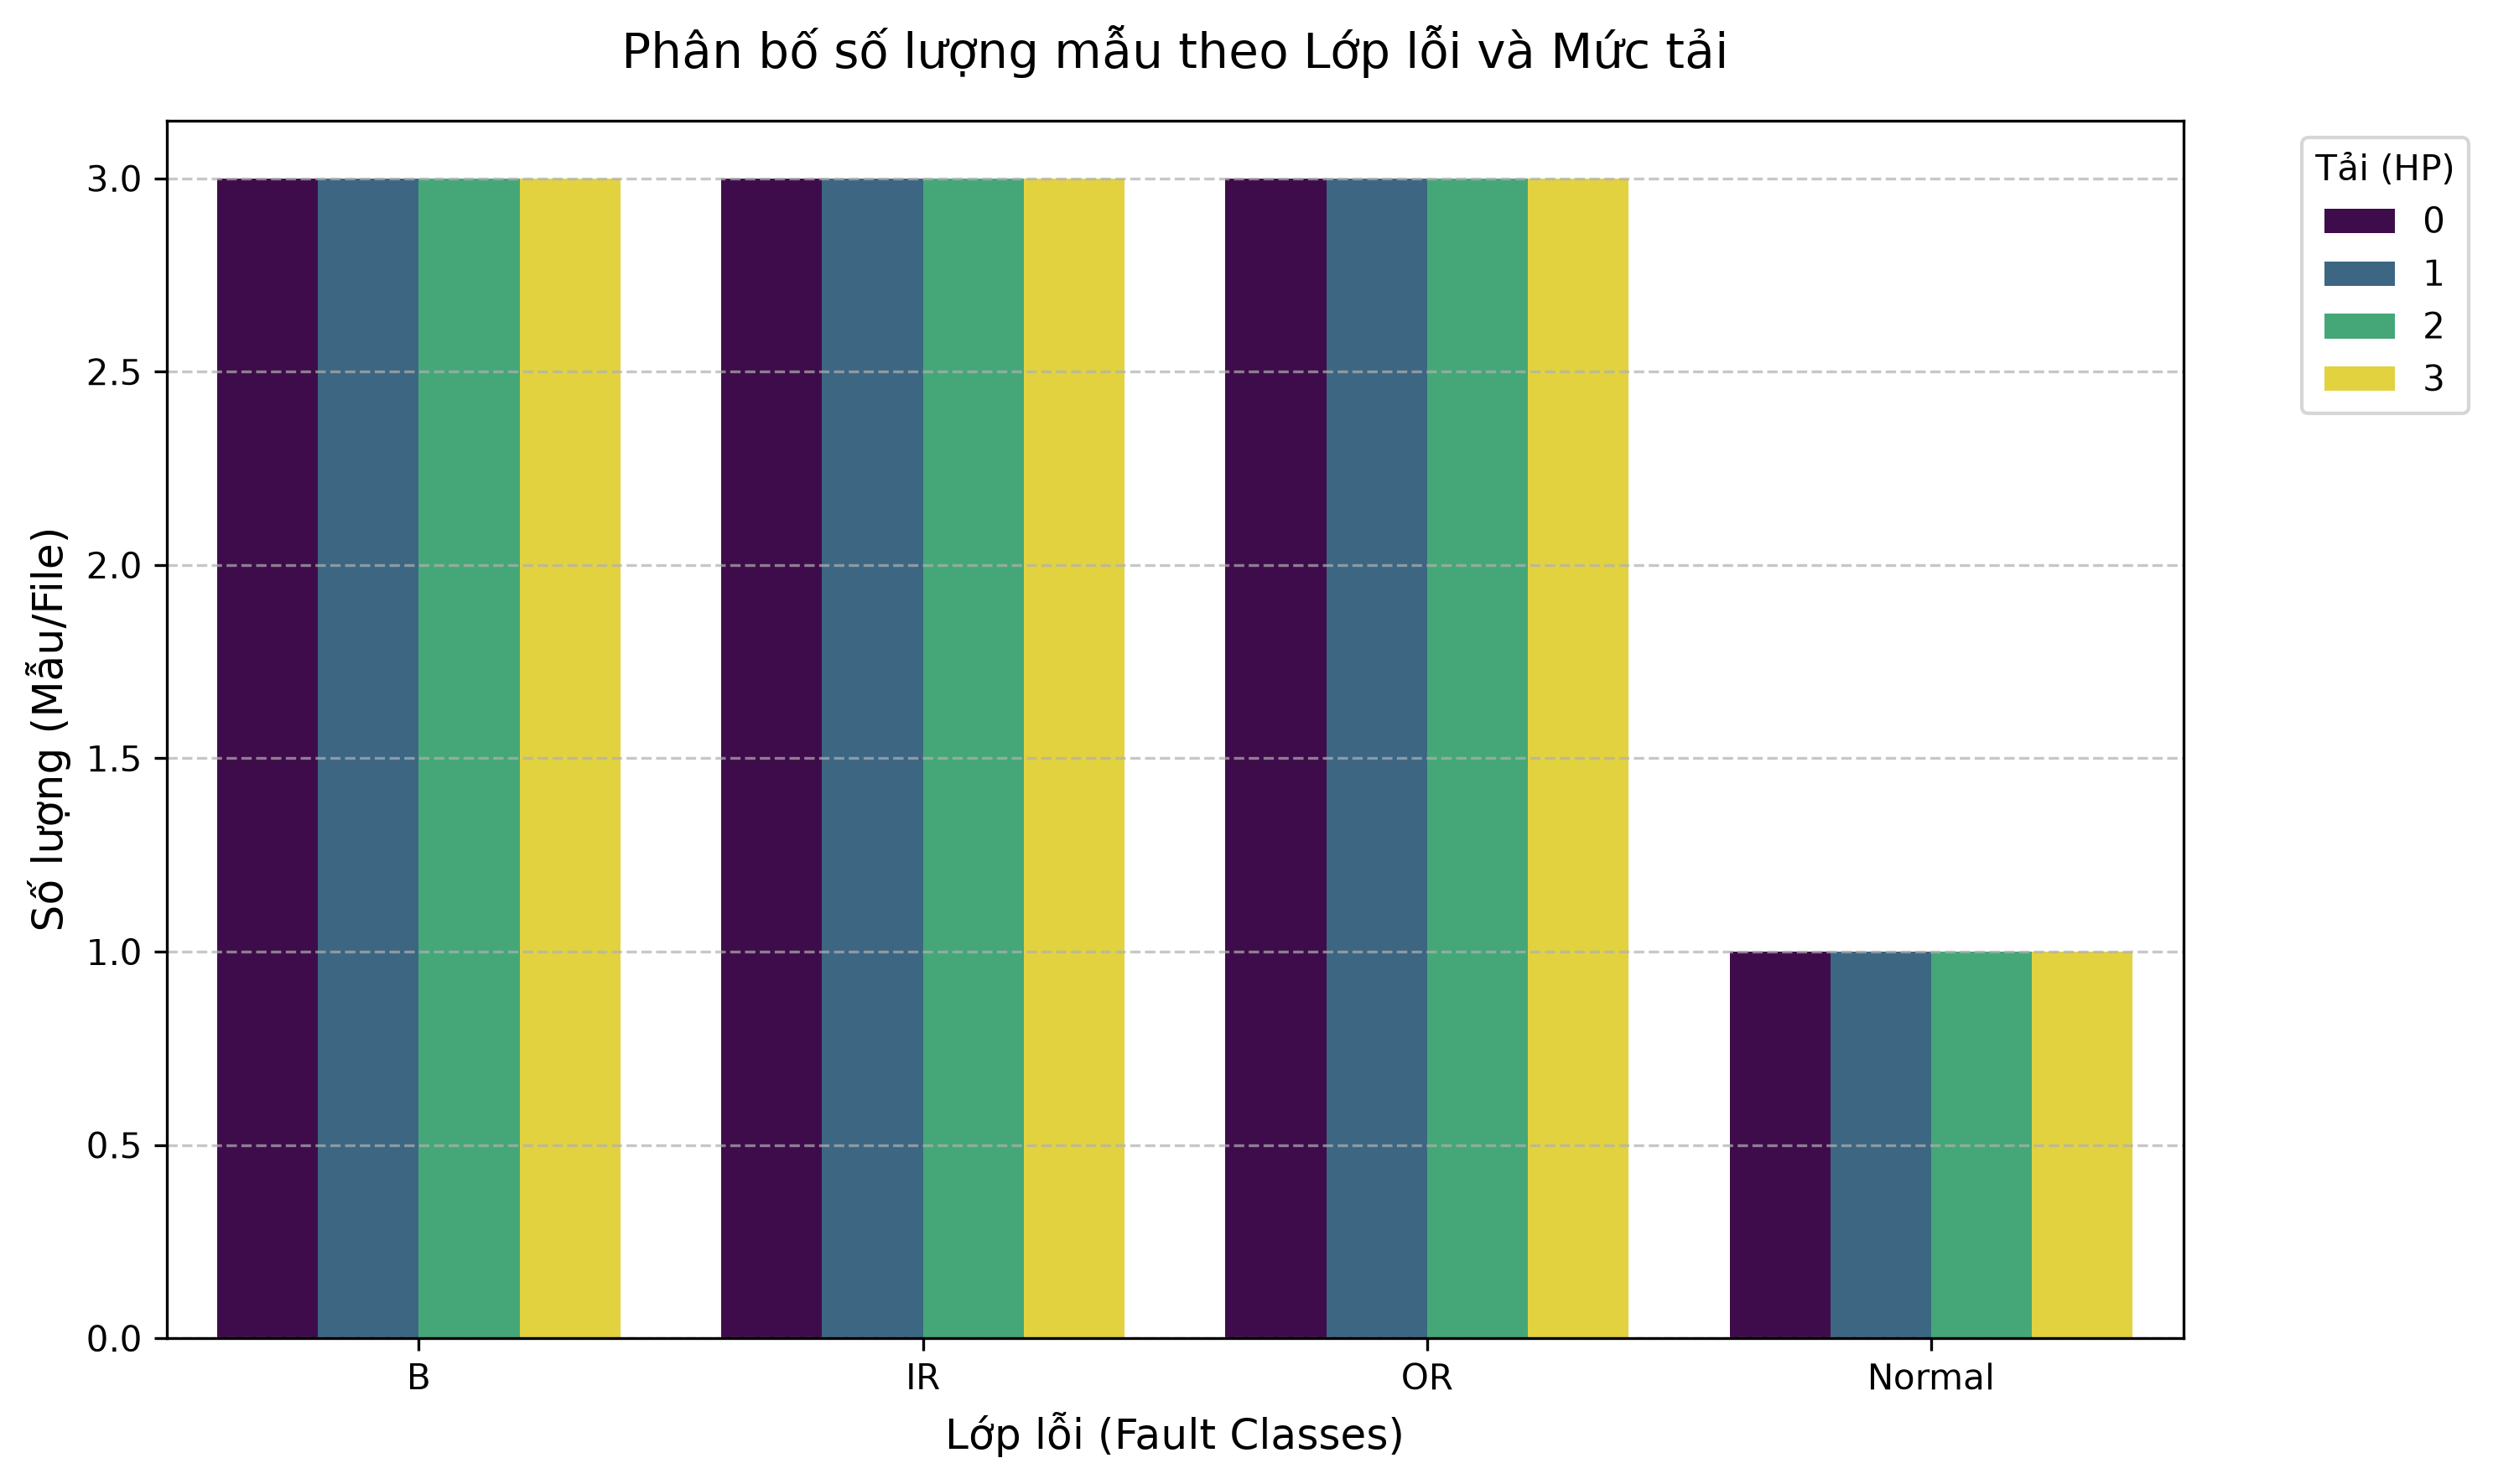

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6), dpi=300)
sns.countplot(data=manifest, x='label', hue='load_hp', palette='viridis')

plt.title('Phân bố số lượng mẫu theo Lớp lỗi và Mức tải', fontsize=14, pad=15)
plt.xlabel('Lớp lỗi (Fault Classes)', fontsize=12)
plt.ylabel('Số lượng (Mẫu/File)', fontsize=12)
plt.legend(title='Tải (HP)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_data_distribution.png', dpi=300, bbox_inches='tight')
plt.show()